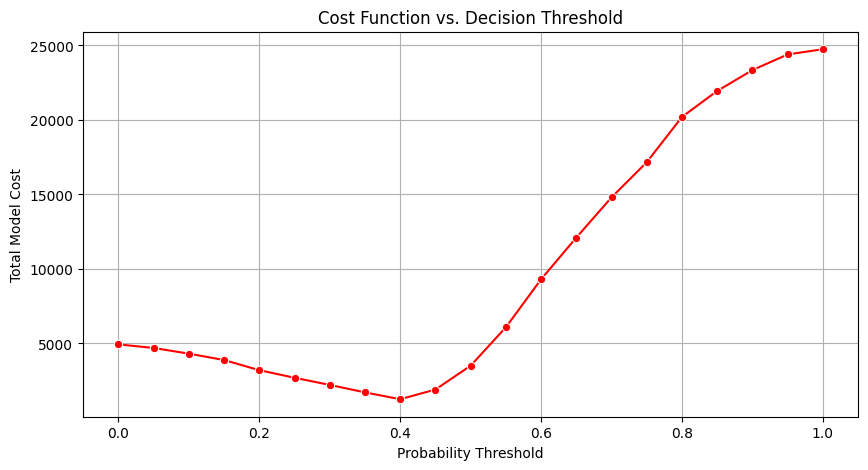


--- Generated Threshold Tuning Sheet ---


,Threshold,Cost,False_Positives,False_Negatives,Sensitivity_Recall,Specificity
0,0.00,4940,494,0,1.0000,0.0000
1,0.05,4700,470,0,1.0000,0.0486
2,0.10,4320,432,0,1.0000,0.1255
3,0.15,3890,389,0,1.0000,0.2126
4,0.20,3210,321,0,1.0000,0.3502
5,0.25,2700,270,0,1.0000,0.4534
6,0.30,2220,222,0,1.0000,0.5506
7,0.35,1720,172,0,1.0000,0.6518
8,0.40,1260,126,0,1.0000,0.7449
9,0.45,1910,86,21,0.9585,0.8259


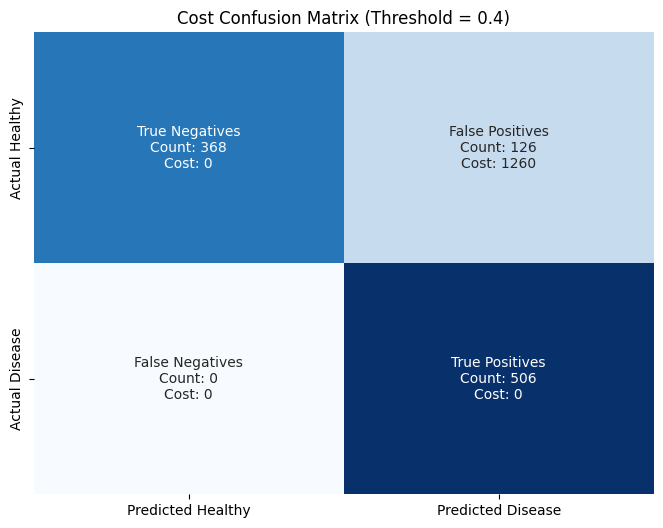


Pipelines successfully executed. Triggering downloads for the Power BI Analyst...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from IPython.display import display # Added to render the table beautifully in Colab

# 1. Derived Metric Transformation Script
def transform_metrics(df):
    """Creates derived categories and risk features for easier Power BI slicing."""
    df_transformed = df.copy()

    # Age binning for demographic statistics
    df_transformed['age_group'] = pd.cut(df_transformed['age'],
                                         bins=[0, 40, 55, 70, 100],
                                         labels=['<40', '40-55', '55-70', '>70'])

    # Clinical risk flags based on standard medical thresholds
    df_transformed['high_blood_pressure'] = np.where(df_transformed['trestbps'] > 130, 1, 0)
    df_transformed['high_cholesterol'] = np.where(df_transformed['chol'] > 240, 1, 0)

    return df_transformed

# 2. Confusion Cost-Matrix Model
def calculate_cost(y_true, y_prob, threshold, fp_cost=10, fn_cost=50):
    """Calculates the financial or clinical cost of predictions at a given threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    total_cost = (fp * fp_cost) + (fn * fn_cost)
    return total_cost, fp, fn, tp, tn

# 3. Decision Threshold Tuning Sheet
def generate_threshold_tuning_sheet(y_true, y_prob):
    """Evaluates probability thresholds from 0.0 to 1.0."""
    thresholds = np.arange(0.0, 1.05, 0.05)
    results = []

    for t in thresholds:
        cost, fp, fn, tp, tn = calculate_cost(y_true, y_prob, t)

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        results.append({
            'Threshold': round(t, 2),
            'Cost': cost,
            'False_Positives': fp,
            'False_Negatives': fn,
            'Sensitivity_Recall': round(sensitivity, 4),
            'Specificity': round(specificity, 4)
        })

    tuning_df = pd.DataFrame(results)

    # Plot Cost Curve
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=tuning_df, x='Threshold', y='Cost', marker='o', color='red')
    plt.title('Cost Function vs. Decision Threshold')
    plt.xlabel('Probability Threshold')
    plt.ylabel('Total Model Cost')
    plt.grid(True)
    plt.show()

    return tuning_df

# 4. Cost Confusion Matrix Visualization
def plot_cost_confusion_matrix(y_true, y_prob, threshold, fp_cost=10, fn_cost=50):
    """Plots a confusion matrix showing patient counts and the associated penalty costs."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    labels = np.array([
        [f"True Negatives\nCount: {tn}\nCost: 0", f"False Positives\nCount: {fp}\nCost: {fp * fp_cost}"],
        [f"False Negatives\nCount: {fn}\nCost: {fn * fn_cost}", f"True Positives\nCount: {tp}\nCost: 0"]
    ])

    counts = np.array([[tn, fp], [fn, tp]])

    plt.figure(figsize=(8, 6))
    sns.heatmap(counts, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=['Predicted Healthy', 'Predicted Disease'],
                yticklabels=['Actual Healthy', 'Actual Disease'])
    plt.title(f'Cost Confusion Matrix (Threshold = {threshold})')
    plt.show()

# --- Execution & Export ---

# Generate a synthetic dataset for 1000 patients
np.random.seed(42)
n_patients = 1000

df_synthetic = pd.DataFrame({
    'patient_id': range(1, n_patients + 1),
    'age': np.random.randint(29, 78, n_patients),
    'trestbps': np.random.randint(94, 200, n_patients),
    'chol': np.random.randint(126, 564, n_patients),
    'actual_disease': np.random.randint(0, 2, n_patients),
})

# FIXED SYNTAX ERROR HERE: Removed the broken newline and corrected the multiplication
df_synthetic['model_probability'] = np.clip(
    (df_synthetic['actual_disease'] * 0.4) + np.random.beta(2, 5, n_patients), 0, 1
)

# 1. Transform metrics
df_final = transform_metrics(df_synthetic)

# 2. Run tuning sheet, DISPLAY IT, & export
y_true = df_final['actual_disease']
y_prob = df_final['model_probability']
tuning_sheet = generate_threshold_tuning_sheet(y_true, y_prob)

print("\n--- Generated Threshold Tuning Sheet ---")
display(tuning_sheet) # This forces Colab to render the table natively on the screen

tuning_sheet.to_csv('threshold_tuning_sheet.csv', index=False)

# 3. Plot the Cost Confusion Matrix (Set to 0.4 to match your minimum cost logic)
OPTIMAL_THRESHOLD = 0.40
plot_cost_confusion_matrix(y_true, y_prob, threshold=OPTIMAL_THRESHOLD)

# 4. Finalize Dataset for Power BI KPIs
df_final['final_prediction'] = (df_final['model_probability'] >= OPTIMAL_THRESHOLD).astype(int)

# Calculate cost per patient row
conditions = [
    (df_final['actual_disease'] == 0) & (df_final['final_prediction'] == 1),
    (df_final['actual_disease'] == 1) & (df_final['final_prediction'] == 0)
]
choices = [10, 50]
df_final['patient_error_cost'] = np.select(conditions, choices, default=0)

# Export Master Dataset
df_final.to_csv('power_bi_kpi_master.csv', index=False)

print("\nPipelines successfully executed. Triggering downloads for the Power BI Analyst...")

# Trigger Colab to download the files to your local machine
files.download('threshold_tuning_sheet.csv')
files.download('power_bi_kpi_master.csv')